# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl (36.7 MB)
Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 14.3 MB/s eta 0:00:00
Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl (70 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("C:\\Users\\nasim\\OneDrive\\Desktop\\DSFall2026\\ds-fall-2026-Week05\\Week-05-Business-Stats-Analytics\\data\\cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [118]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()  # check if there are any duplicated rows left
clean = df.drop_duplicates()


In [119]:
#set all column names to lowercase
clean.columns = clean.columns.str.lower()
#have underscores instead of spaces in column names
clean.columns = clean.columns.str.replace(' ', '_')
clean.head()
clean.shape

(11194, 15)

In [125]:
clean.isna().sum()
clean = clean.dropna()
clean.shape

(11091, 15)

In [127]:
clean.nlargest(10, "highway_mpg")
clean = clean[clean['highway_mpg'] != 354]
clean.nlargest(10, "highway_mpg")
clean.shape

(11091, 15)

In [128]:
clean["engine_cylinders"].value_counts()
#if 0 engine cylinders means they are electric
clean["engine_cylinders"] = clean["engine_cylinders"].replace(0, "electric")
clean["engine_cylinders"].value_counts()
clean.shape

(11091, 15)

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Dupilcate Rows (720) |df.duplicate.sum |720 rows | drop them |because redudant
| 2 |col name messy| just read the original head table |technically all | lowercased & formatted | for standardization|
| 3 | null value in some col | check all col for null |102 rows | drop them |tried to flag, gave up & dropped |
| 4 | outlier highway_mpg| nlargest|1 | remove| error from dataset|
| 5 | 0 enginer cylinders| value counted the engine cylinders| 13 | replaced '0' with 'electric' | better clarification|

In [129]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [133]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 15)
engine_fuel_type     3
engine_hp           69
engine_cylinders    30
number_of_doors      6
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

mean      41933.285957
median    30675.000000
Name: msrp, dtype: float64


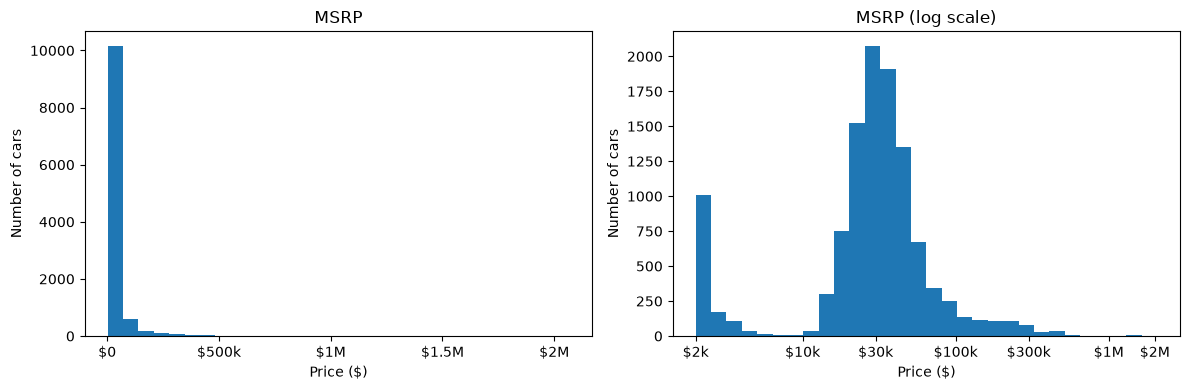

26.7%


In [151]:
# a) print mean and median
print(clean["msrp"].agg(["mean", "median"]))

# b) two histograms side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(clean["msrp"], bins=30)
raw_price_ticks = [0, 500_000, 1_000_000, 1_500_000, 2_000_000]
raw_price_labels = ["$0", "$500k", "$1M", "$1.5M", "$2M"]
ax[0].set_xticks(raw_price_ticks, labels=raw_price_labels)
ax[0].set_title("MSRP")
ax[0].set_xlabel("Price ($)")
ax[0].set_ylabel("Number of cars")

ax[1].hist(np.log10(clean["msrp"]), bins=30)
price_ticks = [2_000, 10_000, 30_000, 100_000, 300_000, 1_000_000, 2_000_000]
price_labels = ["$2k", "$10k", "$30k", "$100k", "$300k", "$1M", "$2M"]
ax[1].set_xticks(np.log10(price_ticks), labels=price_labels)
ax[1].set_title("MSRP (log scale)")
ax[1].set_xlabel("Price ($)")
ax[1].set_ylabel("Number of cars")

plt.tight_layout()
plt.show()

# c) percent of cars above the mean
mean_msrp = clean["msrp"].mean()
share_above_mean = (clean["msrp"] > mean_msrp).mean() * 100
print(f"{share_above_mean:.1f}%")

**Answer:**
A) The mean is larger due to the outliers, there some vehicles priced way higher.
B) Well the mean graph (left) is significantly right skewed due to very few cars being highly priced. The log graph accurately shows the range
C) 26.7% of cars cost more than the mean
D) Median would be better if we're going to general idea


### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [216]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
clean_2017 = clean[clean["year"] == 2017]
mean_std_by_size = clean_2017.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std"])
print(mean_std_by_size)
# b) z = (value - class mean) / class std
clean_2017["highway_mpg_z"] = clean_2017.groupby("vehicle_size")["highway_mpg"].transform(lambda x: (x - x.mean()) / x.std())
print(clean_2017[["vehicle_size", "highway_mpg", "highway_mpg_z"]])

civic_z_score = (42 - 31.994197) / 10.784983
volvo_z_score = (34  - 22.991453) / 3.491184

print(f'civic Z-score: {civic_z_score:.2f} \nVolvo Z-score: {volvo_z_score:.2f}')


                   mean        std
vehicle_size                      
Compact       31.994197  10.784983
Large         22.991453   3.491184
Midsize       29.918623  13.948504
      vehicle_size  highway_mpg  highway_mpg_z
32         Compact           35       0.278703
33         Compact           35       0.278703
34         Compact           35       0.278703
50         Compact           31      -0.092183
51         Compact           32       0.000538
...            ...          ...            ...
11876        Large           23       0.002448
11877        Large           22      -0.283988
11878        Large           22      -0.283988
11879        Large           22      -0.283988
11880        Large           23       0.002448

[1624 rows x 3 columns]
civic Z-score: 0.93 
Volvo Z-score: 3.15


**Answer:** given my data & calculations, the volvo is more efficient as it is 3.15 std above the avg large car, the civic is worse

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

36737.5


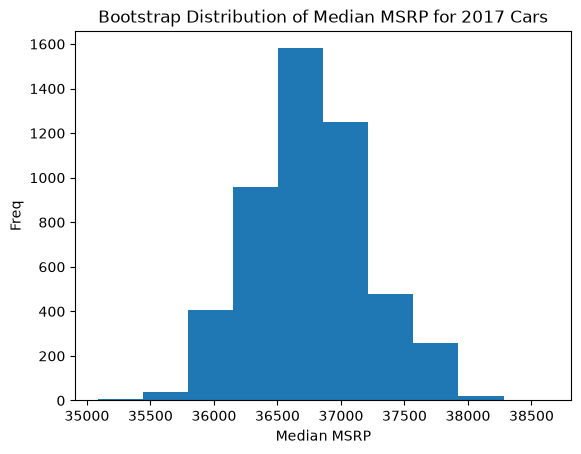

In [ ]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    medians = []
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians.append(np.median(sample))

    return np.array(medians)

# a, b) compute the median of msrp of 2017 cars
clean_2017 = clean[clean["year"] == 2017]
median_msrp_2017 = clean_2017["msrp"].median()
print(median_msrp_2017)

medians = bootstrap_median(clean_2017["msrp"])
plt.hist(medians)
plt.title("Bootstrap Distribution of Median MSRP for 2017 Cars")
plt.xlabel("Median MSRP")
plt.ylabel("Freq")
plt.show()

median_subaru: 25820.0


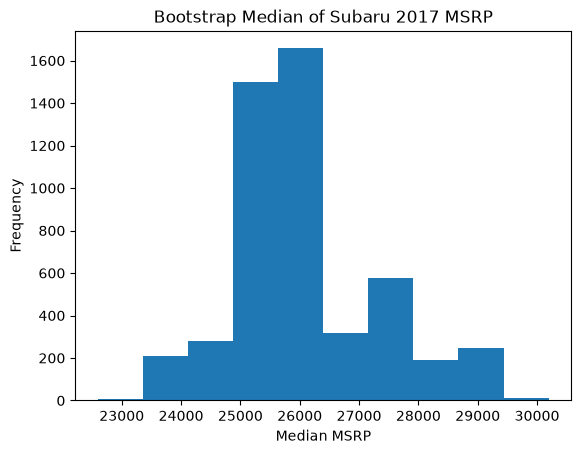

In [198]:
# c) 
clean_2017["make"].value_counts()
subaru_2017 = clean_2017[clean_2017["make"] == "Subaru"]   
subaru_2017.shape #46 

median_subaru = subaru_2017["msrp"].median()
print(f'median_subaru: {median_subaru}') #25820.0

medians = bootstrap_median(subaru_2017["msrp"])

plt.hist(medians)
plt.title("Bootstrap Median of Subaru 2017 MSRP")
plt.xlabel("Median MSRP")
plt.ylabel("Frequency")
plt.show()


**Answer:** 
C) Since I chose the Subaru cars, the interval towards the median is fairly more narrower compared to all the cars, meaning there is a higher concentration at the 50th percentile
D) The median price of subarus regardless of models are around 26,000 dollars

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Number of compact cars in 2017: 517
Mean MPG for compact cars in 2017: 31.994197292069632


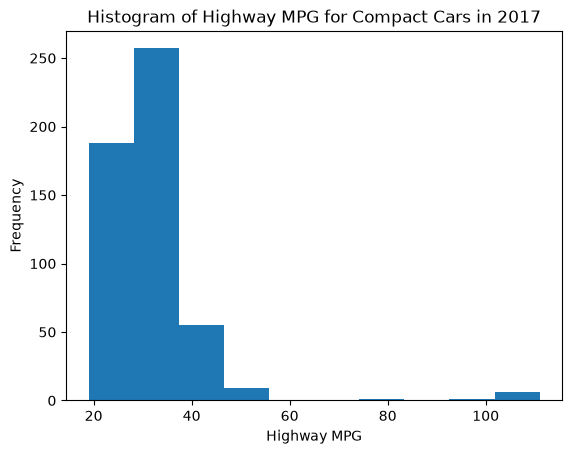

t-statistic: 4.2043 
p-value: 1.5436064323576802e-05


In [232]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_2017 = clean_2017[clean_2017["vehicle_size"] == 'Compact']
numCompact = compact_2017.shape[0]
print(f"Number of compact cars in 2017: {numCompact}")
meanCompact = compact_2017["highway_mpg"].mean()
print(f"Mean MPG for compact cars in 2017: {meanCompact}")

plt.hist(compact_2017["highway_mpg"])
plt.xlabel("Highway MPG")
plt.ylabel("Frequency")
plt.title("Histogram of Highway MPG for Compact Cars in 2017")
plt.show()

# c) one-sample t-test vs 30
result = stats.ttest_1samp(
    compact_2017['highway_mpg'],
    30, 
    alternative="greater"
)
print(f't-statistic: {result.statistic:.4f} \np-value: {result.pvalue}')

# d) rows per make+model, then one row per model and retest

**Answer:**
H₀: The mean MPG of 2017 compact cars is 30 or less
Hₐ: The mean greater than 30

The p-value I got is 1.5, so not sure if my math is wrong or that this is very significant

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [259]:
# a) compare median MSRP by transmission type
clean["transmission_type"].value_counts()
auto_manu_transmission = clean[(clean["transmission_type"] == 'AUTOMATIC') | (clean["transmission_type"] == 'MANUAL')]
auto_manu_transmission["transmission_type"].value_counts()

print(f'Median price for all cars: {auto_manu_transmission["msrp"].median()}')
print(f'Median price for automatic cars: {auto_manu_transmission[auto_manu_transmission["transmission_type"] == "AUTOMATIC"]["msrp"].median()}')
print(f'Median price for manual cars: {auto_manu_transmission[auto_manu_transmission["transmission_type"] == "MANUAL"]["msrp"].median()}')

# b) compare year by transmission type
auto_manu_transmission_by_year = auto_manu_transmission.groupby(["year", "transmission_type"])["msrp"].size().unstack()
auto_manu_transmission_by_year



# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
auto_manu_transmission_2015_2017 = auto_manu_transmission[(auto_manu_transmission["year"] >= 2015) & (auto_manu_transmission["year"] <= 2017)]
auto_manu_transmission_2015_2017.value_counts()

print(f'Median price for all cars (2015-2017): {auto_manu_transmission_2015_2017["msrp"].median()}')

print(f'Median price for automatic cars (2015-2017): {auto_manu_transmission_2015_2017[auto_manu_transmission_2015_2017["transmission_type"] == "AUTOMATIC"]["msrp"].median()}')
print(f'Median price for manual cars (2015-2017): {auto_manu_transmission_2015_2017[auto_manu_transmission_2015_2017["transmission_type"] == "MANUAL"]["msrp"].median()}')

compacts_15_17 = auto_manu_transmission_2015_2017[auto_manu_transmission_2015_2017["vehicle_size"] == "Compact"]
compacts_15_17.value_counts()

auto_comp_15_17 = compacts_15_17[compacts_15_17["transmission_type"] == "AUTOMATIC"]

manual_comp_15_17 = compacts_15_17[compacts_15_17["transmission_type"] == "MANUAL"]

result = stats.mannwhitneyu(auto_comp_15_17["msrp"], manual_comp_15_17["msrp"])


print(f'\np-value: {result.pvalue}')


Median price for all cars: 30045.0
Median price for automatic cars: 33007.5
Median price for manual cars: 19385.0
Median price for all cars (2015-2017): 35917.5
Median price for automatic cars (2015-2017): 37065.0
Median price for manual cars (2015-2017): 26905.0

p-value: 0.20483161191397048


**Answer:** No significant diff in price

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [267]:
# a) Welch t-test, 4-door vs 2-door
clean['number_of_doors'].value_counts()

four_door_cars = clean[clean['number_of_doors'] == 4.0]['highway_mpg']
two_door_cars = clean[clean['number_of_doors'] == 2.0]['highway_mpg']

result = stats.ttest_ind(four_door_cars, two_door_cars, equal_var=False)

print(f'Average MPG for 4-door cars: {four_door_cars.mean():.2f}')
print(f'Average MPG for 2-door cars: {two_door_cars.mean():.2f}')
print(f'Difference in means: {four_door_cars.mean() - two_door_cars.mean():.2f}')
print(f'p-value: {result.pvalue}')


# b) yearly gas cost = miles * price_per_gallon / mpg
four_door_cost = 12000 * 3.50 / four_door_cars.mean()
two_door_cost = 12000 * 3.50 / two_door_cars.mean()

print(f'\n\n4-door yearly cost: ${four_door_cost:.2f}')
print(f'2-door yearly cost: ${two_door_cost:.2f}')
print(f'4-door yearly savings ${two_door_cost - four_door_cost:.2f}')

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    four_door_sample = rng.choice(four_door_cars, 30, replace=False)
    two_door_sample = rng.choice(two_door_cars, 30, replace=False)
    result = stats.ttest_ind(four_door_sample, two_door_sample, equal_var=False)
    if result.pvalue < 0.05:
        hits += 1
        
print(f'\n\nsignificant Fraction: {hits / n_sims}')

Average MPG for 4-door cars: 27.37
Average MPG for 2-door cars: 25.34
Difference in means: 2.03
p-value: 1.0864597874518932e-36


4-door yearly cost: $1534.41
2-door yearly cost: $1657.50
4-door yearly savings $123.09


significant Fraction: 0.155


**Answer:** I think we can get away with saying it in an AD

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** Manual cars had a lower median MSRP ($19,385) than automatics ($33,007.50), but this does not account for other differences between the cars. Among 2015–2017 compact cars, the Mann–Whitney test found no significant price difference (p = 0.205). Four-door cars averaged 27.37 highway MPG versus 25.34 for two-door cars, saving about $123 annually in fuel. However, only 15.5% of simulated samples detected a significant MPG difference. Since the data uses 1990–2017 MSRP values and includes multiple trims of the same models, the results may not fully represent today’s market.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2